### 验证所有数据归一化(在剩余总额中的比例)后是否符合理论上的均匀分布

对于第$i$个抢红包者，我们假定在其抢红包前剩余的金额为$R_i$，剩余的人数为$k$，其获得的红包金额为$X_i$。那么，$$X_i \sim Uni(0.1\frac{R_i}{k}, 2\frac{R_i}{k})$$,即符合0.1倍剩余均值到2倍剩余均值的均匀分布。

我们对于480组8人抢40元红包的数据进行验证：

首先将每轮抢得金额得原始数据归一化为其占剩余总金额得比例，然后验证是否属于均匀分布。

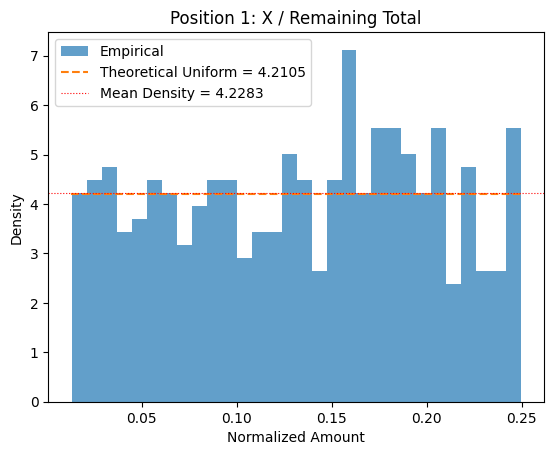

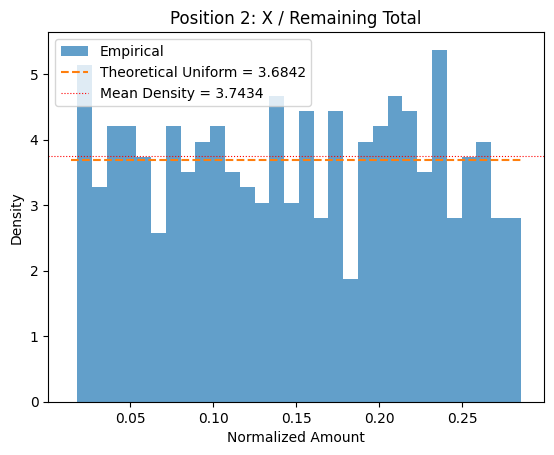

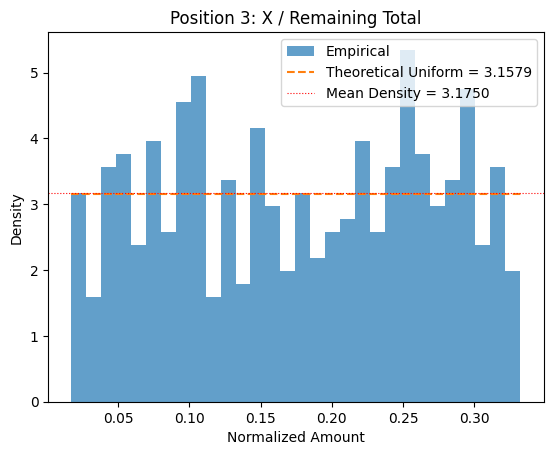

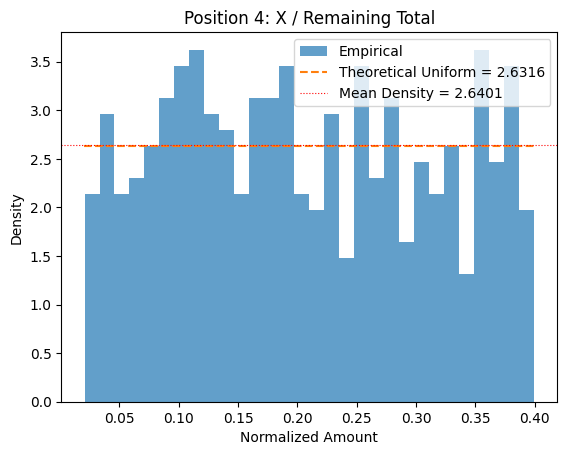

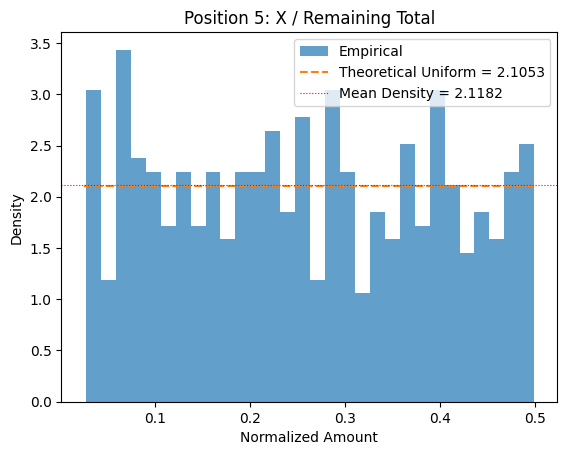

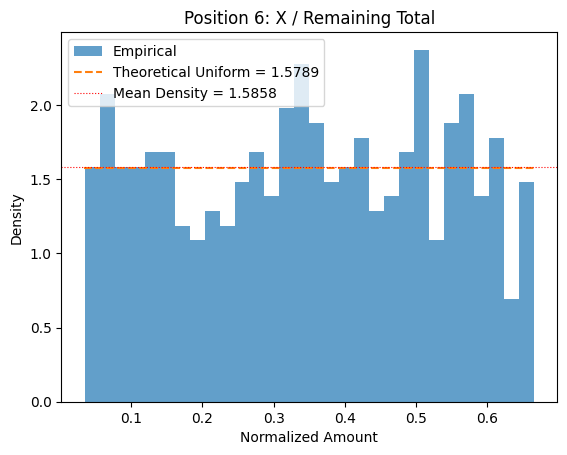

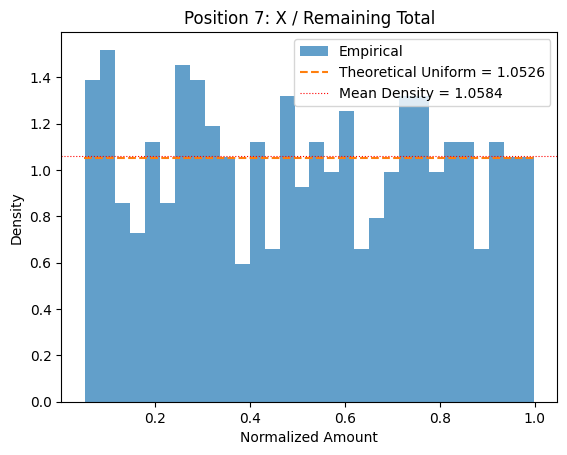

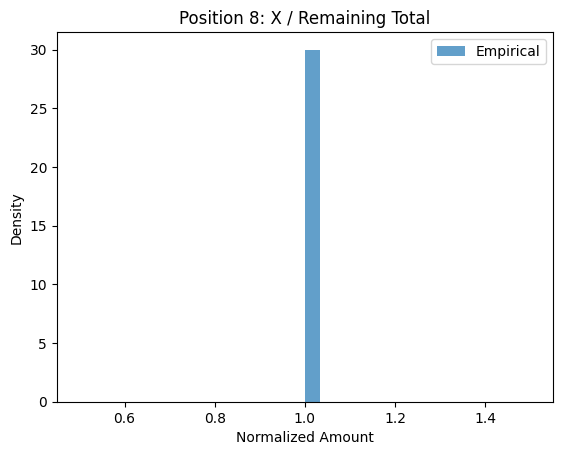

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =====================
# 1. 读取数据
# =====================
# 假设:
# 行 = 实验次数
# 列 = 位次 (第1个抢到的人, 第2个, ...)
df = pd.read_csv("envelopes.csv")

# Skip the 'Trial' column (first column)
df_data = df.iloc[:, 1:]

num_positions = df_data.shape[1]

# =====================
# 2. 计算归一化比例
# =====================
ratios = {}

for i, col in enumerate(df_data.columns):
    # 剩余总额（包含自己）
    remaining_sum = df_data.iloc[:, i:].sum(axis=1)
    ratios[col] = df_data[col] / remaining_sum

ratio_df = pd.DataFrame(ratios)

# =====================
# 3. 绘制直方图验证均匀分布
# =====================
for i, col in enumerate(ratio_df.columns):
    data = ratio_df[col].dropna()
    bins = 30

    # 先用 numpy 计算密度（便于求均值）
    counts, edges = np.histogram(data, bins=bins, density=True)
    bin_centers = (edges[:-1] + edges[1:]) / 2

    # 绘制直方图（density=True）
    plt.figure()
    plt.hist(data, bins=bins, density=True, alpha=0.7, label="Empirical")

    if i < num_positions - 1:
        # 理论均匀分布区间（从0到上界）
        upper = 2 / (num_positions - i)
        lower = 0.1 / (num_positions - i)

        # 理论常数密度 = 总概率(1) / 区间长度
        theoretical_density = 1.0 / (upper - lower)

        # 经验密度的均值（所有bin的密度平均）
        mean_density = counts.mean()

        # 绘制理论密度和经验均值密度
        x = np.linspace(lower, upper, 200)
        y = np.ones_like(x) / (upper - lower)

        plt.plot(x, y, linestyle="--", label=f"Theoretical Uniform = {y[0]:.4f}")
        plt.axhline(mean_density, color='red', linestyle=':', linewidth=0.8,
                    label=f'Mean Density = {mean_density:.4f}')

    plt.title(f"Position {i+1}: X / Remaining Total")
    plt.xlabel("Normalized Amount")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

K-S检验

In [109]:
from scipy.stats import kstest

print("Kolmogorov–Smirnov Test Results")
print("-" * 50)

for i, col in enumerate(ratio_df.columns):
    # 理论均匀分布的上界
    upper = 2 / (num_positions - i)

    # 经验样本
    data = ratio_df[col].dropna().values

    # KS 检验
    # H0: data ~ Uniform(0, upper)
    ks_stat, p_value = kstest(
        data,
        'uniform',
        args=(0, upper)
    )

    print(
        f"Position {i+1:2d} | "
        f"KS statistic = {ks_stat:.4f} | "
        f"p-value = {p_value:.4f}"
    )

    # Pass/fail message in English
    if p_value > 0.05:
        print("Passes KS test")
    else:
        print("Fails KS test")
    
    print()


Kolmogorov–Smirnov Test Results
--------------------------------------------------
Position  1 | KS statistic = 0.0717 | p-value = 0.0135
Fails KS test

Position  2 | KS statistic = 0.0469 | p-value = 0.2335
Passes KS test

Position  3 | KS statistic = 0.0489 | p-value = 0.1946
Passes KS test

Position  4 | KS statistic = 0.0468 | p-value = 0.2346
Passes KS test

Position  5 | KS statistic = 0.0493 | p-value = 0.1874
Passes KS test

Position  6 | KS statistic = 0.0484 | p-value = 0.2034
Passes KS test

Position  7 | KS statistic = 0.0487 | p-value = 0.1977
Passes KS test

Position  8 | KS statistic = 0.5000 | p-value = 0.0000
Fails KS test



Position2-7能够通过K-S检验。Position 1无法通过得原因可能是左侧“保底机制”导致得异常值影响过大。Position 8（末位）的金额完全取决于剩余，不具有独立性，证明该猜想基本正确。

### 求解第 2 个红包金额 ($X_2$) 的概率密度函数（显式解）


* 总金额：( m )
* 总人数：( n )
* 第一个红包金额：
  $$
  X_1 \sim \mathrm{Uni}\left(0,; \frac{2m}{n}\right)
  $$
* 第二个人抢红包前的剩余金额：
  $$
  R_2 = m - X_1
  $$
* 条件分布规则：
  $$
  X_2 \mid R_2
  \sim
  \mathrm{Uni}\left(
    \frac{0.1R_2}{n-1},
  \frac{2R_2}{n-1}
  \right)
  $$
* 不过在$n \ge 1$时，保底机制对于分布整体的影响可以忽略不计，为方便计算，我们将条件分布规则简化为：
  $$
  X_2 \mid R_2
  \sim
  \mathrm{Uni}\left(
    0,
  \frac{2R_2}{n-1}
  \right)
  $$

---

给定 ($R_2 = r$)，由于
$$
X_1 \sim \mathrm{Uni}\left(0,\frac{2m}{n}\right)
$$

作变量变换 ($R_2 = m - X_1$)，得到：

$$
R_2 \sim \mathrm{Uniform}!\left(
m - \frac{2m}{n}, m
\right)
$$

即：

$$
f_{R_2}(r)=

\frac{n}{2m}
\mathbf{1}_{\left[m-\frac{2m}{n},m\right]}(r)
$$


根据全概率公式：

$$
f_{X_2}(x)=\int f_{X_2 \mid R_2}(x \mid r); f_{R_2}(r),dr
$$

代入得到：

$$
f_{X_2}(x)=\int
\frac{n-1}{2r}
\cdot
\frac{n}{2m}
;
\mathbf{1}_{\left[
\max\left(m-\frac{2m}{n},;\frac{(n-1)x}{2}\right),;m
\right]}(r)
;dr
$$


积分下限是两者中的最大值：

$$
r_{\min}(x)=\max\left(
m-\frac{2m}{n},;
\frac{(n-1)x}{2}
\right)
$$

这导致 **PDF 是分段函数**。

定义临界点：

$$
x_0=\frac{2}{n-1}
\left(m-\frac{2m}{n}\right)=\frac{2m(n-2)}{n(n-1)}
$$

当 $0 \le x \le \dfrac{2m(n-2)}{n(n-1)}$

此时：
$$
r_{\min} = m-\frac{2m}{n}
$$

$$
\boxed{
f_{X_2}(x)=\frac{n(n-1)}{4m}
\ln\left(\frac{n}{n-2}\right)
}
$$


当 $\dfrac{2m(n-2)}{n(n-1)} < x \le \dfrac{2m}{n-1}$

此时：
$$
r_{\min} = \frac{(n-1)x}{2}
$$

$$
\boxed{
f_{X_2}(x)=\frac{n(n-1)}{4m}
\ln\left(
\frac{2m}{(n-1)x}
\right)
}
$$

其余情况,

$$
f_{X_2}(x) = 0
$$

---

综上，

$$
\boxed{
f_{X_2}(x)=
\begin{cases}
\dfrac{n(n-1)}{4m}
\ln\left(\dfrac{n}{n-2}\right),
& 0 \le x \le \dfrac{2m(n-2)}{n(n-1)}, [1.2em]
\dfrac{n(n-1)}{4m}
\ln\left(
\dfrac{2m}{(n-1)x}
\right),
& \dfrac{2m(n-2)}{n(n-1)} < x \le \dfrac{2m}{n-1}, [1.2em]
0,
& \text{otherwise}.
\end{cases}
}
$$

如下图所示：

Total amount m = 40.0
Participant Number n= 8
Max empirical X2 = 10.86
Theoretical upper bound = 11.428571428571429
A= 0.10068872535812329
x_flat= 8.571428571428571
C= 0.35


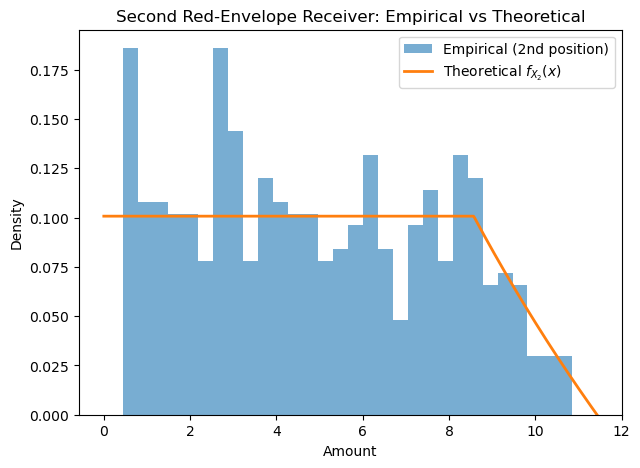

In [110]:
import numpy as np
import matplotlib.pyplot as plt

# =====================
# 基本参数
# =====================
# 第二个抢红包的数据
x2_data = df.iloc[:-1, 2].values

n = df.shape[1]-1                      # 人数
m = df.sum(axis=1, numeric_only=True).iloc[1]  # 总金额（从第一行取得）
print("Total amount m =", m)
print("Participant Number n=", n)
print("Max empirical X2 =", x2_data.max())
print("Theoretical upper bound =", 2 * m / (n - 1))


# =====================
# 理论 PDF 定义
# =====================
def f_X2(x, n, m):
    x = np.asarray(x)
    pdf = np.zeros_like(x, dtype=float)

    a = 2 * m * (n - 2) / (n * (n - 1))
    b = 2 * m / (n - 1)
    c = n * (n - 1) / (4 * m)

    mask1 = (x >= 0) & (x <= a)
    pdf[mask1] = c * np.log(n / (n - 2))

    mask2 = (x > a) & (x <= b)
    pdf[mask2] = c * np.log((2 * m) / ((n - 1) * x[mask2]) )

    print("A=",c * np.log(n / (n - 2)))
    print("x_flat=",a)
    print("C=",c)

    return pdf

# =====================
# 作图：经验直方图 + 理论曲线
# =====================
x_grid = np.linspace(0, 2 * m / (n - 1), 500)
pdf_vals = f_X2(x_grid, n, m)

plt.figure(figsize=(7,5))
plt.hist(
    x2_data,
    bins=30,
    density=True,
    alpha=0.6,
    label="Empirical (2nd position)"
)

plt.plot(
    x_grid,
    pdf_vals,
    linewidth=2,
    label=r"Theoretical $f_{X_2}(x)$"
)

plt.xlabel("Amount")
plt.ylabel("Density")
plt.title("Second Red-Envelope Receiver: Empirical vs Theoretical")
plt.legend()
plt.show()

随着$i$的增加，解析式会包含更高阶的多重对数或多项式，形式极其复杂。但我们可以定性描述其分布特征：
期望值不变，不难证明，对于任意 $1\le i \le n$，都有$$E[X_i]=\frac{m}{n}$$

方差增大：$i=1$时是均匀分布，方差最小，只能取到平均值的0到2倍。

$i$越大，剩余金额$S_i$的不确定性越大。后面的人有可能面临“前面的人抢很少，剩下一大笔钱”（从而抢到远超2倍均值的金额），也有可能面临“前面的人抢完了，只剩渣”（抢到0）。

分布图会变得**低而宽**，即取值范围变大，但概率密度峰值降低。

### 求解$X_k$的近似PDF

#### 关键观察

* $X_1$ 在区间 $[0, 2m/n]$ 上均匀
* $X_2$ 在小金额区间内也具有**常数密度**


根据**卷积的标准结论**：

> 两个在 $[0,a]$、$[0,b]$ 上密度常数的随机变量，其和在 $[0,\min(a,b)]$ 上仍然密度常数。

因此：

$
S_2 := X_1 + X_2
$

在一个初始区间内，其密度为：

$
f_{S_2}(s) = \text{常数}, \quad s \in [0, s_0]
$


因此，在前半区间第3个红包的金额：
$$
f_{X_3}(x)=\mathbb E\left[\frac{n-2}{2(m-X_1-X_2)}\right]
$$

对 (X_1,X_2) 取期望：

$$
f_{X_3}(x)=A=\frac{n-2}{2}
\mathbb E\left[\frac{1}{m-X_1-X_2}\right]
$$

$$
\mathbb E\left[\frac{1}{m-X_1-X_2}\right]=\int_0^{2m/n}\int_0^{2(m-x_1)/(n-1)}
\frac{n(n-1)}{4m(m-x_1)}
\cdot
\frac{1}{m-x_1-x_2}
,dx_2,dx_1
$$

先对 (x_2) 积分：

$$
\int_0^{2(m-x_1)/(n-1)}\frac{dx_2}{m-x_1-x_2}=\ln\frac{m-x_1}{m-x_1-\frac{2(m-x_1)}{n-1}}

\ln\frac{n-1}{n-3}
$$

这是一个**常数**。

于是：

$$
\boxed{
f_{X_3}(x)=A
=

\frac{n(n-2)}{4m}
\ln\frac{n-1}{n-3}
}
$$

#### 尾部衰减区间的主导机制


当 (x) 较大时，必须满足：

$
R_3 \ge \frac{(n-2)x}{2}
\quad\Rightarrow\quad
X_1 + X_2 \le m - \frac{(n-2)x}{2}
$


在尾部区间：

* $X_1$ 和 $X_2$ 的上界成为主要限制
* 可近似认为：
  $$
  X_1, X_2 \stackrel{\text{i.i.d.}}{\sim}
  \mathrm{Uniform}(0,2m/n)
  $$

于是 $S_2 = X_1 + X_2$ 的密度近似为**三角分布**：

$$
f_{S_2}(s)
\propto
\left(1 - \frac{s}{4m/n}\right)
$$


其中：

* (C, c) 是由 (m,n) 决定的常数
* 对数的 **平方** 来自：

  * 一次来自 (X_2) 的混合
  * 一次来自 (X_1) 的混合


> 第三个红包金额 (X_3) 的概率密度函数由两部分构成：在一段初始区间内，由于前两次分配的卷积效应，其分布呈现均匀平台；在尾部区间，大额红包只能在前两次分配均较小的情形下出现，其概率密度表现为对数平方形式的缓慢衰减。



因此无条件密度为
$$
f_{X_3}(x)=\mathbb E!\left[
\frac{n-2}{2(m-X_1-X_2)}
;\mathbf 1!\left(
x\le \frac{2(m-X_1-X_2)}{n-2}
\right)
\right]
$$

其中，c为尾部的最大可能值：

$$
\boxed{
c=\frac{2m}{n-2}
}
$$

由归一化条件：

$$
A,x_{\text{flat}}
+
C\int_{x_{\text{flat}}}^{c}
\left[\ln!\left(\frac{c}{x}\right)\right]^2dx=1$$

计算积分：

令 ($u=\ln(c/x)$)，则

$$
\int u^2 e^{-u}du=e^{-u}(u^2+2u+2)
$$

于是：

$$
\int_{x_{\text{flat}}}^{c}
\left[\ln!\left(\frac{c}{x}\right)\right]^2dx=c
\Bigl[
2
-

\frac{x_{\text{flat}}}{c}
\Bigl(
\ln^2\frac{c}{x_{\text{flat}}}
+
2\ln\frac{c}{x_{\text{flat}}}
+
2
\Bigr)
\Bigr]
$$


$$
C
=
\frac{
1-A,x_{\text{flat}}
}{
c
\Bigl[
2
-

\frac{x_{\text{flat}}}{c}
\Bigl(
\ln^2\frac{c}{x_{\text{flat}}}
+
2\ln\frac{c}{x_{\text{flat}}}
+
2
\Bigr)
\Bigr]
}

$$


#### 推广到一般 $X_k$

**上界(最大可能值)**
$$
\boxed{
c_k=\frac{2m}{,n-k+1,}
}
$$

**平坦区右端点**

$$
\boxed{
x_{\mathrm{flat}}^{(k)}
=

\frac{2m}{,n-k+1,}
\prod_{i=0}^{k-2}
\frac{n-i-2}{n-i}
}
$$

**平坦区高度**
$$
\boxed{
A_k
=

\frac{n(n-k+1)}{4m}
\ln\frac{n-k+1}{n-k-1}
}
$$

**尾部系数（由连续性确定）**

$$
\boxed{
C_k=
\frac{
A_k
}{
\left[
\ln\left(
\dfrac{c_k}{x_{\mathrm{flat}}^{(k)}}
\right)
\right]^{k-1}
}
}
$$

**分段概率密度函数**

$$
\boxed{
f_{X_k}(x)
=

\begin{cases}
A_k,
& 0 \le x \le x_{\mathrm{flat}}^{(k)}, [0.8em]
C_k
\left[
\ln!\left(
\dfrac{c_k}{x}
\right)
\right]^{k-1},
& x_{\mathrm{flat}}^{(k)} < x \le c_k, [0.8em]
0,
& \text{otherwise}.
\end{cases}
}
$$

---




1.计算参数

In [15]:
from scipy.integrate import quad

def theoretical_params_Xk(k, n, m):
    # x_flat^{(k)}
    prod = 1.0
    for i in range(k - 1):
        prod *= (n - i - 2) / (n - i)
    x_flat = (2 * m / (n - k + 1)) * prod

    # 平坦区高度 A_k
    A = (n * (n - k + 1) / (4 * m)) * np.log((n - k + 2) / (n - k))

    # 理论上界
    c = 2 * m / (n - k + 1)

    # 初始 C_k（由连续性确定）
    C_init = A / (np.log(c / x_flat) ** (k - 1))

    # =====================
    # 归一化操作：确保积分为1
    # =====================
    # 定义临时PDF函数
    def pdf_temp(x):
        if x <= x_flat:
            return A
        elif x <= c:
            return C_init * (np.log(c / x) ** (k - 1))
        else:
            return 0.0

    # 数值积分计算总面积
    total_integral, _ = quad(pdf_temp, 0, c)
    
    # 计算缩放因子（使得积分 = 1）
    scale_factor = 1.0 / total_integral if total_integral > 0 else 1.0
    
    # 归一化后的参数
    A = A * scale_factor
    C = C_init * scale_factor

    return A, x_flat, C, c


2.理论PDF

In [16]:
def f_Xk(x, k, n, m):
    x = np.asarray(x)
    pdf = np.zeros_like(x, dtype=float)

    A, x_flat, C, c = theoretical_params_Xk(k, n, m)

    mask1 = (x >= 0) & (x <= x_flat)
    pdf[mask1] = A

    mask2 = (x > x_flat) & (x <= c)
    pdf[mask2] = C * (np.log(c / x[mask2]) ** (k - 1))

    return pdf


3.验证第k个红包：经验 vs 理论

In [17]:
def validate_Xk(df, k, bins=30):
    # 第 k 个红包数据
    xk_data = df.iloc[:-1, k].values

    n = df.shape[1] - 1
    m = df.sum(axis=1, numeric_only=True).iloc[1]

    A, x_flat, C, c = theoretical_params_Xk(k, n, m)

    print(f"=== X_{k} theoretical parameters ===")
    print("A =", A)
    print("x_flat =", x_flat)
    print("c =", c)
    print("C =", C)
    print("Empirical max =", xk_data.max())

    x_grid = np.linspace(0, c, 600)
    pdf_vals = f_Xk(x_grid, k, n, m)

    plt.figure(figsize=(7, 5))
    plt.hist(
        xk_data,
        bins=bins,
        density=True,
        alpha=0.6,
        label=f"Empirical (position {k})"
    )
    plt.plot(
        x_grid,
        pdf_vals,
        linewidth=2,
        label=rf"Theoretical $f_{{X_{k}}}(x)$"
    )

    plt.axvline(x_flat, linestyle="--", color="black", alpha=0.7,
                label=r"$x_{\mathrm{flat}}$")

    plt.xlabel("Amount")
    plt.ylabel("Density")
    plt.title(f"Position {k}: Empirical vs Theoretical")
    plt.legend()
    plt.show()


=== X_2 theoretical parameters ===
A = 0.10068872535812333
x_flat = 8.571428571428571
c = 11.428571428571429
C = 0.3499999999999999
Empirical max = 11.08


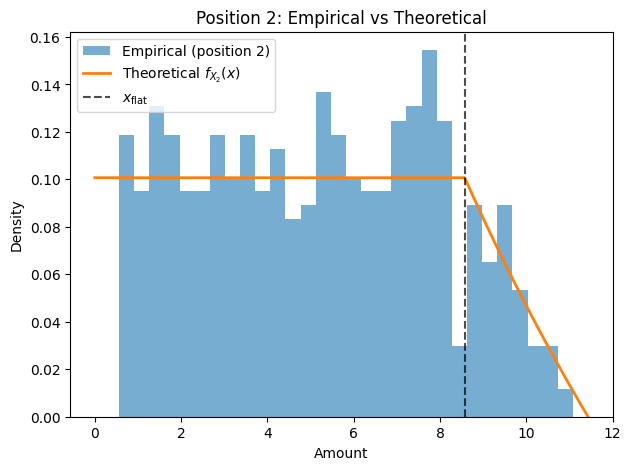

=== X_3 theoretical parameters ===
A = 0.11244706198894568
x_flat = 7.142857142857143
c = 13.333333333333334
C = 0.288645084706654
Empirical max = 11.42


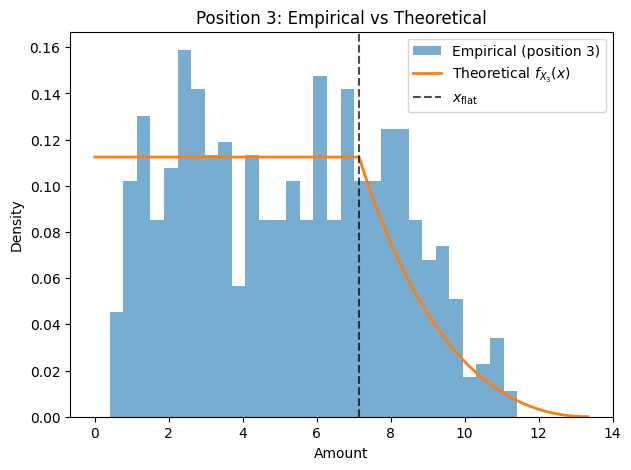

=== X_4 theoretical parameters ===
A = 0.13247151963008252
x_flat = 5.7142857142857135
c = 16.0
C = 0.12136468857441524
Empirical max = 12.85


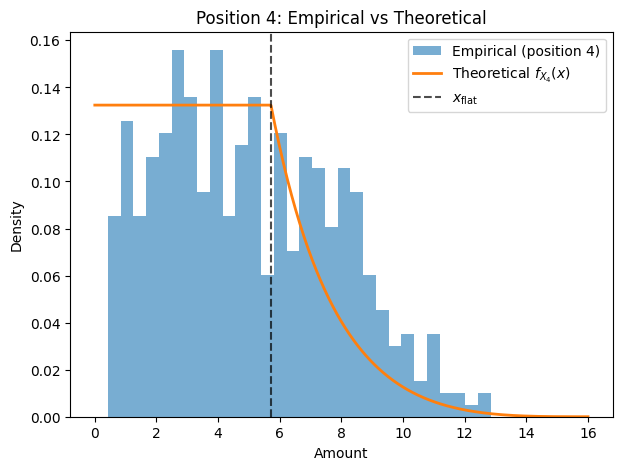

=== X_5 theoretical parameters ===
A = 0.16564641750848053
x_flat = 4.285714285714285
c = 20.0
C = 0.029416920982938934
Empirical max = 14.14


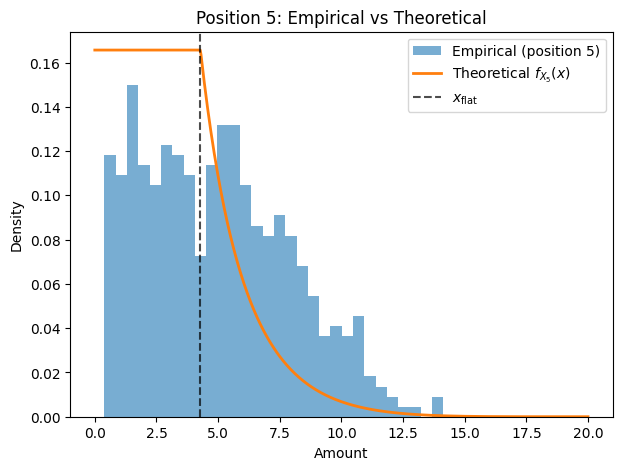

=== X_6 theoretical parameters ===
A = 0.22805166949595404
x_flat = 2.8571428571428568
c = 26.666666666666668
C = 0.004102171503216978
Empirical max = 14.59


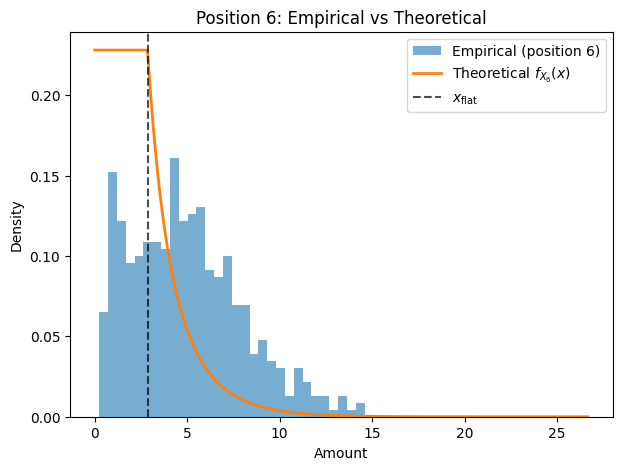

=== X_7 theoretical parameters ===
A = 0.3927426967425693
x_flat = 1.4285714285714282
c = 40.0
C = 0.00028689186295097966
Empirical max = 20.62


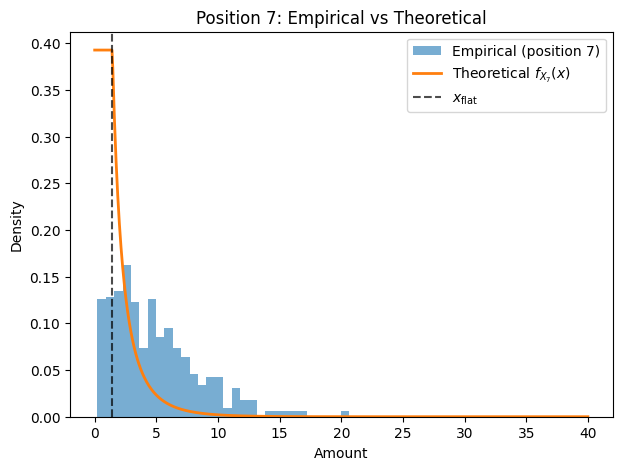

In [19]:
validate_Xk(df, k=2)
validate_Xk(df, k=3)
validate_Xk(df, k=4)
validate_Xk(df, k=5)
validate_Xk(df, k=6)
validate_Xk(df, k=7)

